In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("../data/raw/cleaned_base_deceptive_reviews.csv")

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())


Dataset shape: (1600, 4)

First few rows:


,Label,HotelName,Sentiment,Review
0,truthful,conrad,positive,We stayed for a one night getaway with family ...
1,truthful,hyatt,positive,Triple A rate with upgrade to view room was le...
2,truthful,hyatt,positive,This comes a little late as I'm finally catchi...
3,truthful,omni,positive,The Omni Chicago really delivers on all fronts...
4,truthful,hyatt,positive,I asked for a high floor away from the elevato...



Column names:
['Label', 'HotelName', 'Sentiment', 'Review']

Data types:
Label        object
HotelName    object
Sentiment    object
Review       object
dtype: object

Missing values:
Label        0
HotelName    0
Sentiment    0
Review       0
dtype: int64


In [2]:
# Rename columns if needed
df.rename(columns={"Label": "label", "Review": "review"}, inplace=True)

# Keep required columns only
df = df[["review", "label"]]

# Drop missing values
df.dropna(inplace=True)

print("After cleaning:", df.shape)
display(df.head())


After cleaning: (1600, 2)


,review,label
0,We stayed for a one night getaway with family ...,truthful
1,Triple A rate with upgrade to view room was le...,truthful
2,This comes a little late as I'm finally catchi...,truthful
3,The Omni Chicago really delivers on all fronts...,truthful
4,I asked for a high floor away from the elevato...,truthful


In [3]:
import re

def clean_text(text):
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text.lower().strip()

df["cleaned_review"] = df["review"].astype(str).apply(clean_text)

display(df[["review", "cleaned_review"]].head())


,review,cleaned_review
0,We stayed for a one night getaway with family ...,we stayed for a one night getaway with family ...
1,Triple A rate with upgrade to view room was le...,triple a rate with upgrade to view room was le...
2,This comes a little late as I'm finally catchi...,this comes a little late as im finally catchin...
3,The Omni Chicago really delivers on all fronts...,the omni chicago really delivers on all fronts...
4,I asked for a high floor away from the elevato...,i asked for a high floor away from the elevato...


In [4]:
label_map = {"truthful": 0, "deceptive": 1}
df["label_encoded"] = df["label"].map(label_map)

print(df["label_encoded"].value_counts())


label_encoded
0    800
1    800
Name: count, dtype: int64


In [5]:
X = df["cleaned_review"]
y = df["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (1280,)
Test size: (320,)


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)


TF-IDF shape: (1280, 5000)


In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

print("✅ Model trained successfully")


✅ Model trained successfully


In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.896875

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.89      0.90       160
           1       0.89      0.91      0.90       160

    accuracy                           0.90       320
   macro avg       0.90      0.90      0.90       320
weighted avg       0.90      0.90      0.90       320



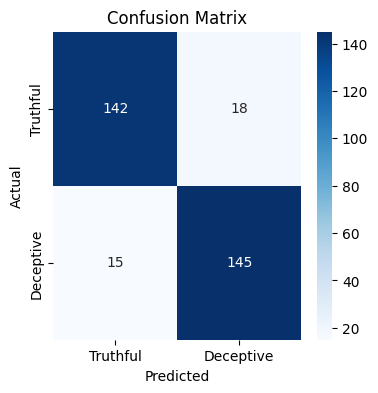

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Truthful", "Deceptive"],
    yticklabels=["Truthful", "Deceptive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [10]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/review_model.pkl")
joblib.dump(vectorizer, "models/vectorizer.pkl")

print("✅ Model & vectorizer saved")


✅ Model & vectorizer saved
